# Лабораторна робота 2 — Проста лінійна регресія (аналітичний розв'язок)


**Набір даних:** `kc_house_data.csv`  
**Обмеження:** scikit-learn-регресія **не дозволена** для базових завдань.

## Налаштування

In [1]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib --quiet


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline


## Теоретичне підґрунтя

Для однієї вхідної ознаки **x** та виходу **y** аналітичний розв'язок МНК:
```
slope     = ( Σ(xᵢ·yᵢ) − n·x̄·ȳ )  /  ( Σ(xᵢ²) − n·x̄² )
intercept = ȳ − slope · x̄
```
Сума квадратів залишків (RSS):
```
RSS = Σ ( yᵢ − (intercept + slope·xᵢ) )²
```

---
## Завдання 1 — Підготовка даних

Завантажте `kc_house_data.csv`. Розбийте на **навчальну (20 %) та тестову (80 %)** вибірки з `random_state=0`.

In [3]:
sales = pd.read_csv('/home/kc_house_data.csv')
train_data, test_data = train_test_split(sales, test_size=0.8, random_state=0)
print(f'Навчальна: {len(train_data)} рядків  |  Тестова: {len(test_data)} рядків')


Навчальна: 4322 рядків  |  Тестова: 17291 рядків


---
## Завдання 2 — Реалізація `simple_linear_regression()`

Завершіть функцію, використовуючи **лише NumPy** (без sklearn, без циклів по рядках).

In [5]:
def simple_linear_regression(input_feature, output):
    """
    Обчислює slope та intercept МНК для однієї ознаки.

    Параметри
    ----------
    input_feature : array-like, shape (n,)
    output        : array-like, shape (n,)

    Повертає
    -------
    intercept, slope : float, float
    """
    input_feature = np.array(input_feature, dtype=float)
    output        = np.array(output, dtype=float)
    n = len(input_feature)

    # Compute slope
    avg_x = np.mean(input_feature)
    avg_y = np.mean(output)
    slope = (np.sum(input_feature * output) - n *  avg_x * avg_y) / (np.sum(input_feature ** 2) - n * (avg_x ** 2))

    # Compute intercept
    intercept = avg_y - slope * avg_x

    return intercept, slope


### Перевірка — обидва значення нижче мають дорівнювати **1.0**

In [6]:
test_feature = np.arange(5, dtype=float)
test_output  = 1.0 + 1.0 * test_feature
test_intercept, test_slope = simple_linear_regression(test_feature, test_output)
print(f'Intercept: {test_intercept:.4f}  (очікується 1.0)')
print(f'Slope    : {test_slope:.4f}  (очікується 1.0)')


Intercept: 1.0000  (очікується 1.0)
Slope    : 1.0000  (очікується 1.0)


### Навчання на `sqft_living`

In [7]:
sqft_intercept, sqft_slope = simple_linear_regression(
    train_data['sqft_living'], train_data['price']
)
print(f'Вільний член: {sqft_intercept:.2f}')
print(f'Нахил: {sqft_slope:.4f}')


Вільний член: -29748.29
Нахил: 273.5299


---
## Завдання 3 — Передбачення та RSS

**а)** Реалізуйте `get_regression_predictions(input_feature, intercept, slope)` — повертає масив NumPy передбачених значень.  
**б)** Реалізуйте `get_residual_sum_of_squares(input_feature, output, intercept, slope)` — обчислює RSS.  
**в)** Перевірте обидві функції, потім вкажіть RSS на навчальній і тестовій вибірках та дайте відповідь на питання нижче.

In [9]:
def get_regression_predictions(input_feature, intercept, slope):
    """Повертає масив передбачених значень."""
    return intercept + slope * input_feature


In [10]:
def get_residual_sum_of_squares(input_feature, output, intercept, slope):
    """Повертає RSS (скаляр)."""
    return np.sum((output - get_regression_predictions(input_feature, intercept, slope)) ** 2)


### Перевірка — RSS на тестових вхідних даних має бути **0.0**

In [11]:
rss_check = get_residual_sum_of_squares(
    test_feature, test_output, test_intercept, test_slope
)
print(f'RSS на тестових вхідних даних: {rss_check:.2f}  (очікується 0.0)')


RSS на тестових вхідних даних: 0.00  (очікується 0.0)


### RSS для моделі `sqft_living`

In [12]:
rss_train = get_residual_sum_of_squares(
    train_data['sqft_living'], train_data['price'],
    sqft_intercept, sqft_slope
)
rss_test = get_residual_sum_of_squares(
    test_data['sqft_living'], test_data['price'],
    sqft_intercept, sqft_slope
)
print(f'Навчальна RSS: {rss_train:.2e}')
print(f'Тестова  RSS: {rss_test:.2e}')


Навчальна RSS: 2.74e+14
Тестова  RSS: 1.20e+15


### Питання — яка передбачувана ціна будинку площею 2 650 кв. футів?

In [14]:
my_house_sqft = 2650
# Завдання 3в — обчисліть і виведіть передбачувану ціну
print("передбачувана ціна будинку: ", get_regression_predictions(my_house_sqft, sqft_intercept, sqft_slope))

передбачувана ціна будинку:  695105.9804007713


---
## Завдання 4 — Порівняння двох ознак

Навчіть другу модель, використовуючи `bedrooms` як вхідну ознаку. Обчисліть RSS на **тестовій вибірці** для обох моделей (`sqft_living` і `bedrooms`). Яка ознака дає кращий прогноз? Поясніть у 2–3 реченнях.

In [15]:
# Навчіть модель на ознаці bedrooms
bedrooms_intercept, bedrooms_slope = simple_linear_regression(
    train_data['bedrooms'], train_data['price']
)
print(f'Вільний член: {bedrooms_intercept:.2f}')
print(f'Нахил: {bedrooms_slope:.4f}')
# Обчисліть тестову RSS для обох моделей
bedrooms_rss_test = get_residual_sum_of_squares(
    test_data['bedrooms'], test_data['price'],
    bedrooms_intercept, bedrooms_slope
)
print(f'Тестова  RSS першої моделі: {rss_test:.2e}')
print(f'Тестова  RSS другої моделі: {bedrooms_rss_test:.2e}')


Вільний член: 195271.72
Нахил: 101863.9402
Тестова  RSS першої моделі: 1.20e+15
Тестова  RSS другої моделі: 2.15e+15


**Відповідь:** Перша модель (побудована за ознакою sqft_living) краще передбачає ціни, оскільки її RSS на тестовій вибірці менша. Це означає, що ознака sqft_living має сильнішу лінійну кореляцію із ціною.

---
## ✨ Бонус — Зворотна регресія

Реалізуйте `inverse_regression_predictions(output, intercept, slope)`, яка розв'язує рівняння регресії у зворотному напрямку: за цільовою ціною оцінює необхідну площу `sqft_living`. Побудуйте пряму регресії на діаграмі розсіювання навчальних даних і позначте точку ($800 000, ваша відповідь) на графіку.

In [16]:

def inverse_regression_predictions(output, intercept, slope):
    """Повертає оцінку input_feature для заданого output."""
    return (output - intercept) / slope


передбачувана площина:  3033.4828109900354


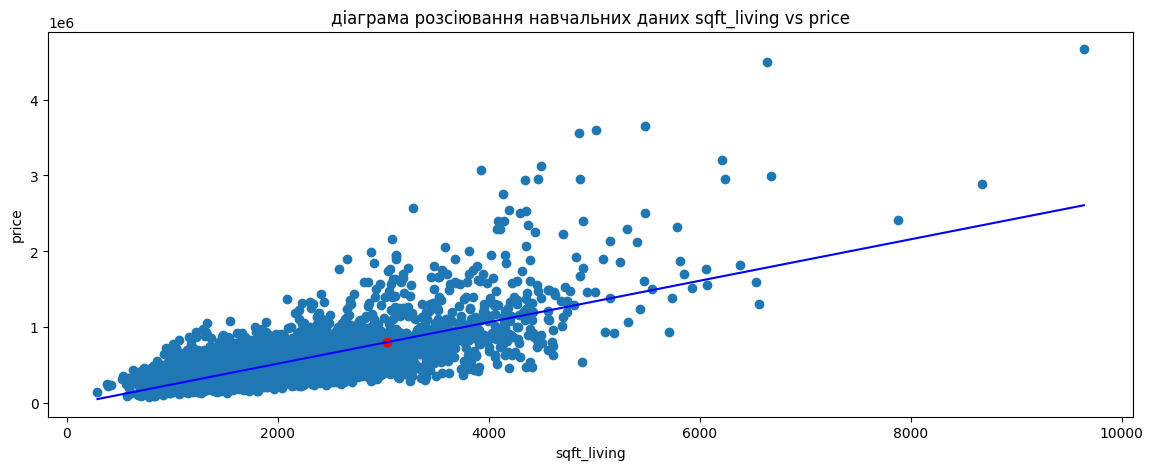

In [33]:
# Бонус — оцініть площу для будинку вартістю $800 000 та побудуйте графік
price = 800000

predict = inverse_regression_predictions(price, sqft_intercept, sqft_slope)
print("передбачувана площина: ", predict)

plt.figure(figsize=(14,5))
plt.scatter(train_data['sqft_living'], train_data['price'])

x = np.array([train_data['sqft_living'].min(), train_data['sqft_living'].max()])
plt.plot(x, get_regression_predictions(x, sqft_intercept, sqft_slope), c='blue')

plt.scatter(predict, price, c='red')
plt.xlabel('sqft_living')
plt.ylabel('price')
plt.title('діаграма розсіювання навчальних даних sqft_living vs price')

plt.show()